In [39]:
!pip install pandas


In [40]:
!pip install seaborn


In [41]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [42]:
!pip install scikit-learn

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
#warning willl remove extra info about packages and other stuff and will avoid the waringings and other data while executing

PATH IS : "C:\Users\dellf\Downloads\Mall_Customers.csv"
but it wont run because of fwd slash unicode error we need to replece all of them with '/'

In [44]:
df = pd.read_csv('C:/Users/dellf/Downloads/Mall_Customers.csv')

df.head()  -   will give the first five readings/data

In [45]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#univariate analysis 

In [46]:
df.describe()
# we will get all stats as mean mode median count max 
#its normal distributio since mean and mode(50%) varry similarly now we'll creat histogram to look at the annual income 
#std is standard deviation



,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

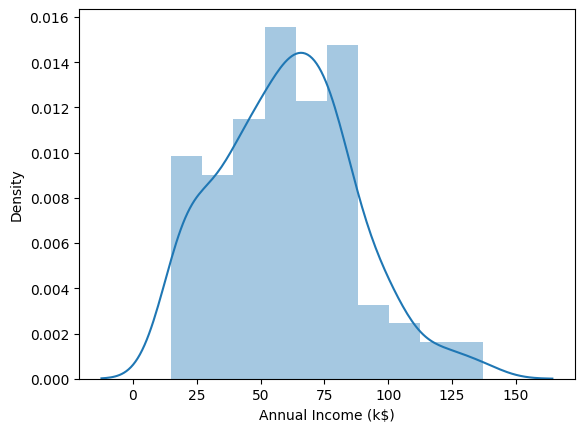

In [47]:
sns.distplot(df['Annual Income (k$)'])

we just want to use numerical variables to look at univariate analysis
so we create a list containing name of coloumns that we want to iterate through for loop

In [48]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

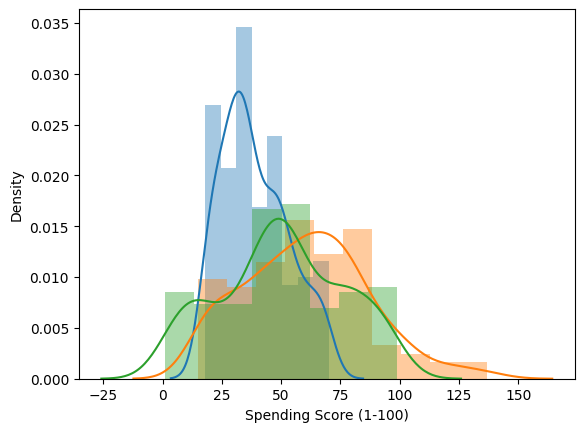

In [ ]:
coloumns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in coloumns:
    plt.Figure()  # so that each time it runs gives a fig/visual
    sns.distplot(df[i]) # for every coloumn using sns
    

instead of histogram as above we do kdeplot here we can also bring in different parameters to add feature and can also separte with dimesions and the main dimension we have in dataset is gender
hue allows us to break data by dimensions

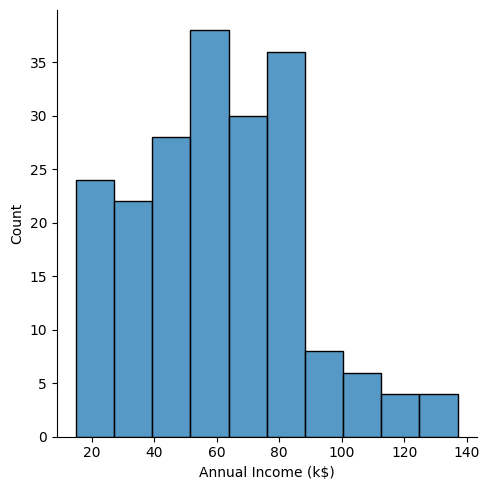

In [50]:
sns.displot(df['Annual Income (k$)'])

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

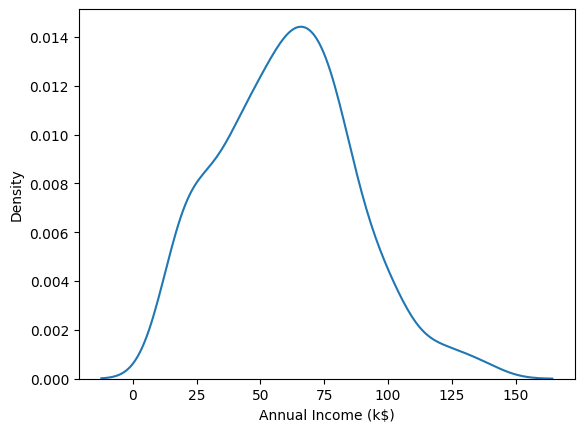

In [51]:
sns.kdeplot(df['Annual Income (k$)'])

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

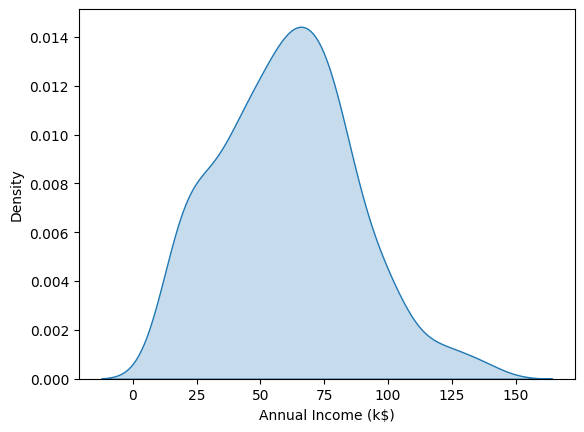

In [55]:
sns.kdeplot(df['Annual Income (k$)'],shade=True)

In [64]:
sns.kdeplot(df['Annual Income (k$)'],shade=True,hue=df['Gender'])

ValueError: The following variable cannot be assigned with wide-form data: `hue`

You're trying to plot a KDE (Kernel Density Estimate) using Seaborn with a hue parameter, but you're getting an error. Based on the line:

python
Copy code
sns.kdeplot(df['Annual Income (k$)'], shade=True, hue=df['Gender'])
The issue is that hue should not be passed like that—hue is a parameter of the full dataset, not of a Series. Here's how to correctly use it:

✅ Correct version:
python
Copy code
sns.kdeplot(data=df, x='Annual Income (k$)', hue='Gender', shade=True)
Notes:
data=df: tells Seaborn to use your DataFrame.

x='Annual Income (k$)': selects the column for the x-axis.

hue='Gender': colors the KDEs by gender.

shade=True adds the fill under the curves (in some newer versions of Seaborn, use fill=True instead—see below).

If shade=True gives a warning or error:
In newer Seaborn versions (0.11.0+), shade was deprecated and replaced with fill. Use this instead:

python
Copy code
sns.kdeplot(data=df, x='Annual Income (k$)', hue='Gender', fill=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

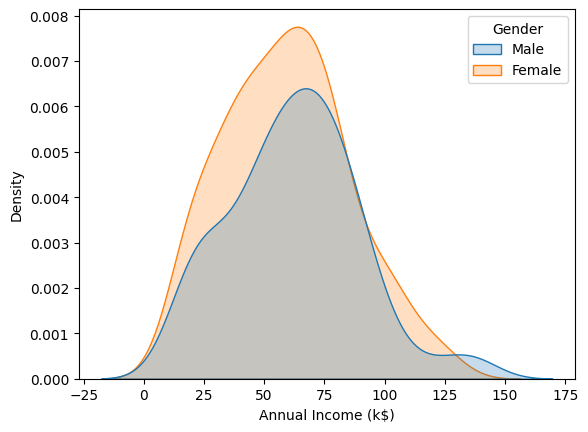

In [60]:
sns.kdeplot(data=df, x='Annual Income (k$)', hue='Gender', shade=True)


Figure clubs all coloums graph anf figure() print individually

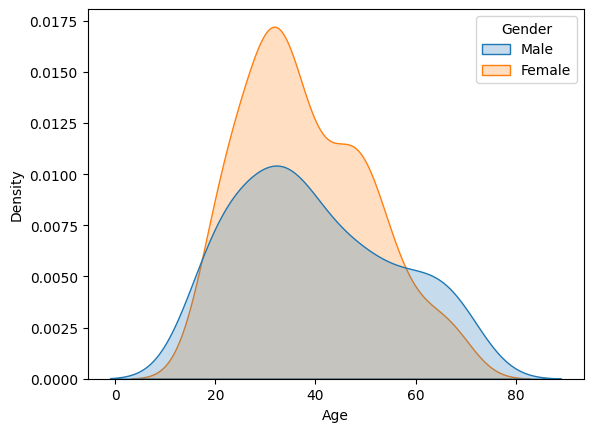

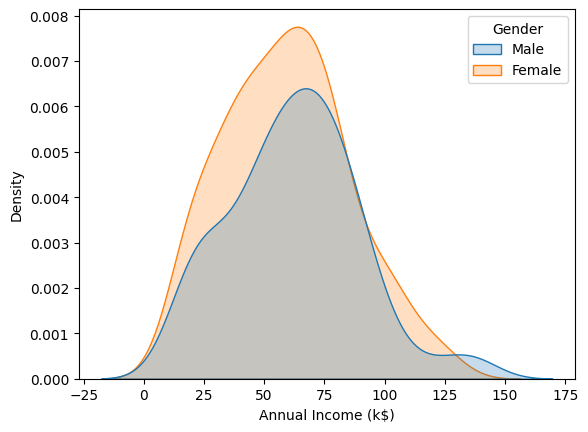

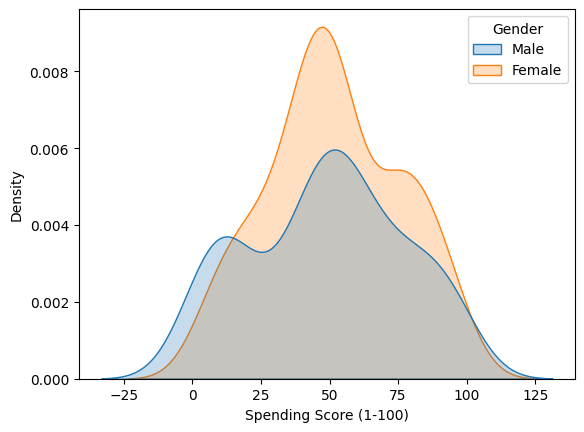

In [70]:
coloumns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in coloumns:
    plt.figure() 
    sns.kdeplot(data=df, x=i, hue='Gender', shade=True)


BOXPLOT() IT CONTAINS X AND Y

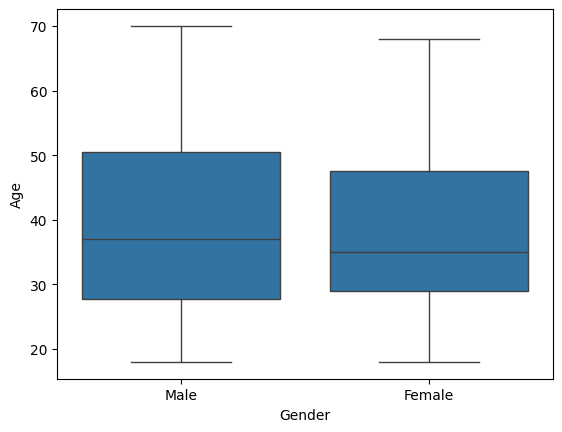

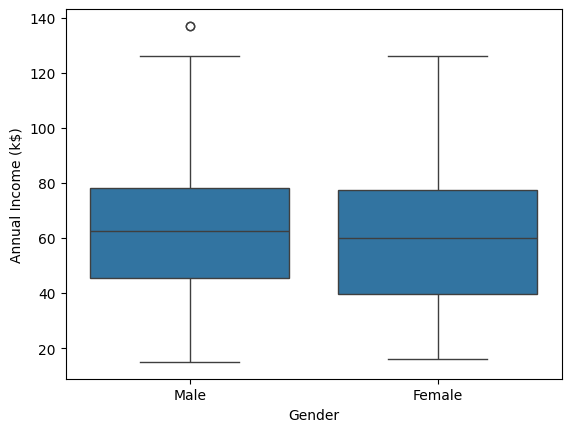

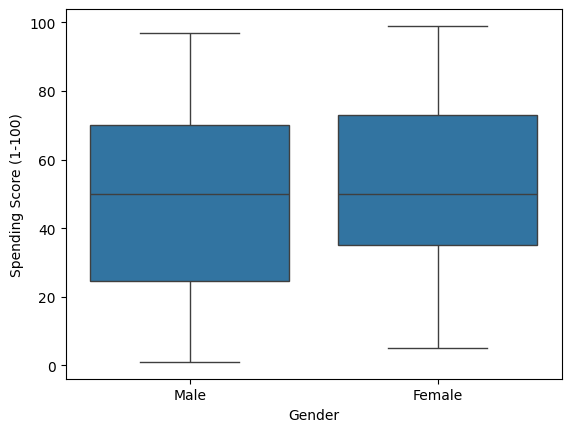

In [71]:
coloumns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in coloumns:
    plt.figure() 
    sns.boxplot(data=df, x='Gender',y=df[i])

In [75]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

if we want this data in percentage we do(normalize = True)

In [77]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

BIVARIATE ANALYSIS

considering two variables. its a scatter plot and very helpful to look at data

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

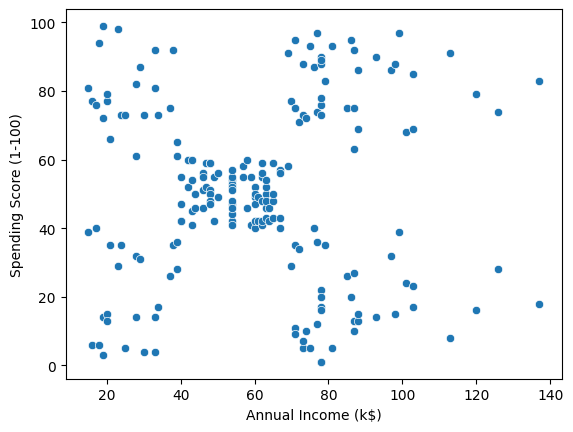

In [79]:
sns.scatterplot(data=df,x='Annual Income (k$)', y='Spending Score (1-100)')

pairplot gives histogram and scatterplot together

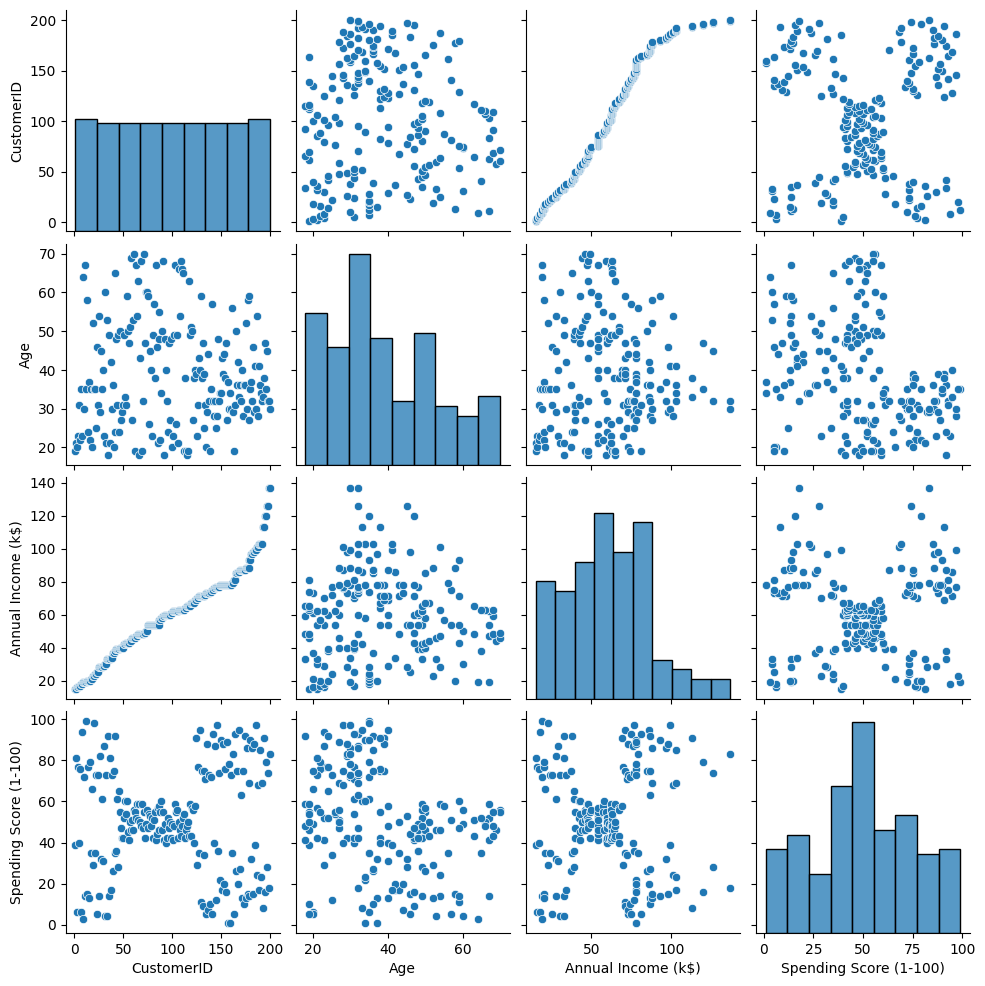

In [80]:
sns.pairplot(df)

Piarplot gives a much data which is not a good practice to fwd all to management or further proceeding .
in order to reduce it we'll eliminate customerid as its not gonna give us any additional information by .drop()

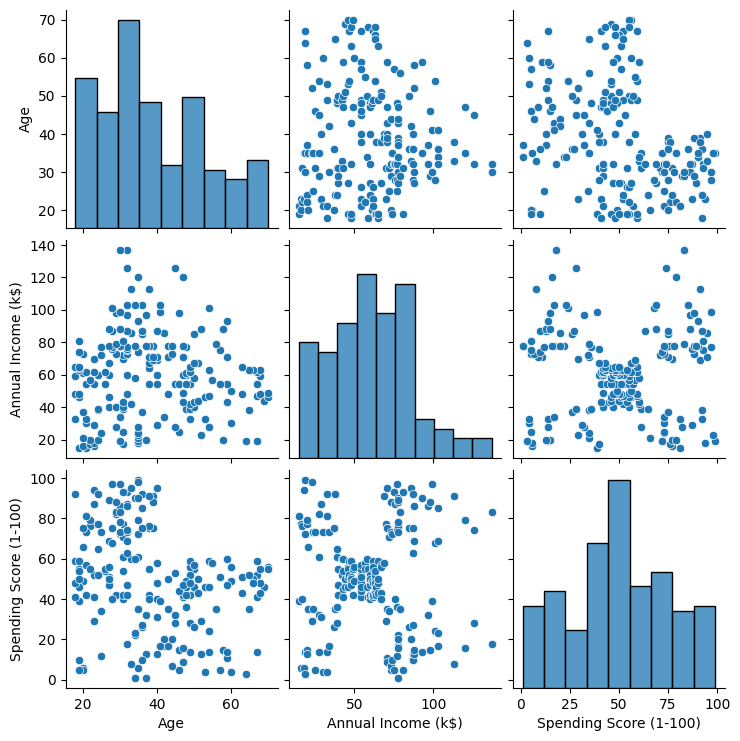

In [81]:
df=df.drop('CustomerID',axis=1)# <- for coloumns and axis=0 for rows
sns.pairplot(df)

observing above data we gonna have max benifit outta above data considering bivariate analysis and choosing two cluster middle rightone and the bottom middle for bivariate

before that 
to generate a lot info together performing hue over gender and we'll observe that the plaot changes again to previous ones and clusters all is a lot of information

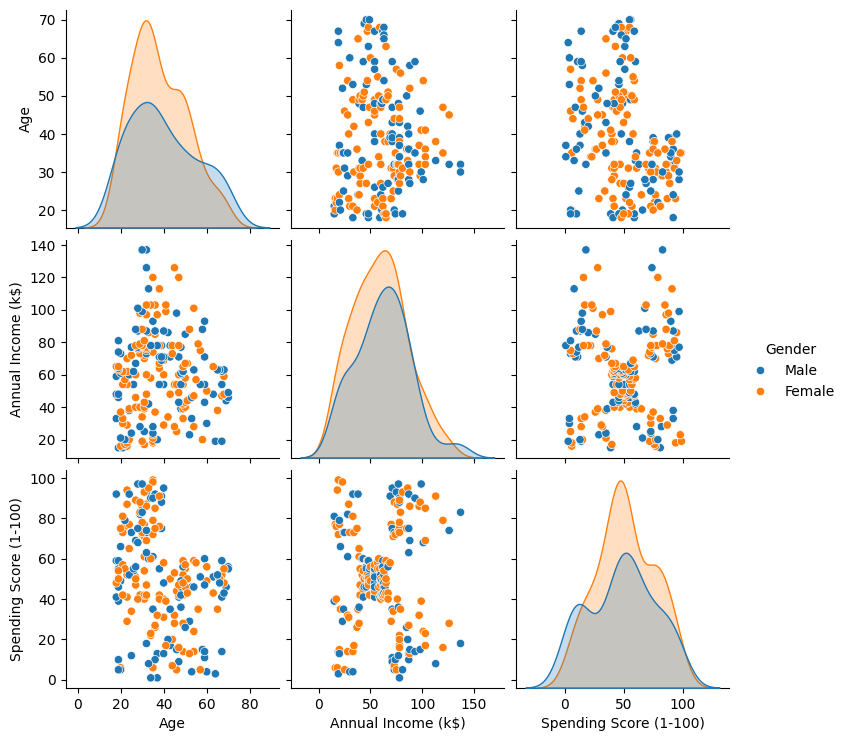

In [83]:
#df=df.drop('CustomerID',axis=1)
sns.pairplot(df,hue='Gender')

now i want to know the mean value based on gender because we wonna see whats the difference between two using GROUP BY 
mean values groupby Gender

In [88]:
df.groupby(['Gender'])['Age', 'Annual Income (k$)','Spending Score (1-100)'].mean()

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

This syntax used to work in older versions of pandas, but now it's best to use double square brackets when selecting multiple columns.

In [89]:
df.groupby(['Gender'])[['Age', 'Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


[[]] is used to select multiple columns properly after the groupby.

we got a lot of bivariate information 
now we'll figure out the correlation by .corr() func

 If you're getting a ValueError with df.corr(), it’s likely not about the syntax (since df.corr() is valid), but rather about the contents of your DataFrame.
Possible causes:
Non-numeric columns: df.corr() only works on numeric columns. If your DataFrame contains non-numeric columns (like strings, objects, categories, etc.), it might throw an error depending on how pandas tries to handle them.

All columns are non-numeric: If there are no numeric columns, it will raise an error like:


In [93]:
df.corr()

ValueError: could not convert string to float: 'Male'

ValueError: could not convert string to float

FIXES IN df.corr()

In [ ]:


df.select_dtypes(include='number').corr()


,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


creating heatmap using saeborn and gonna pass this correlation and also wanna see the color mapping i.e.cmap


<Axes: >

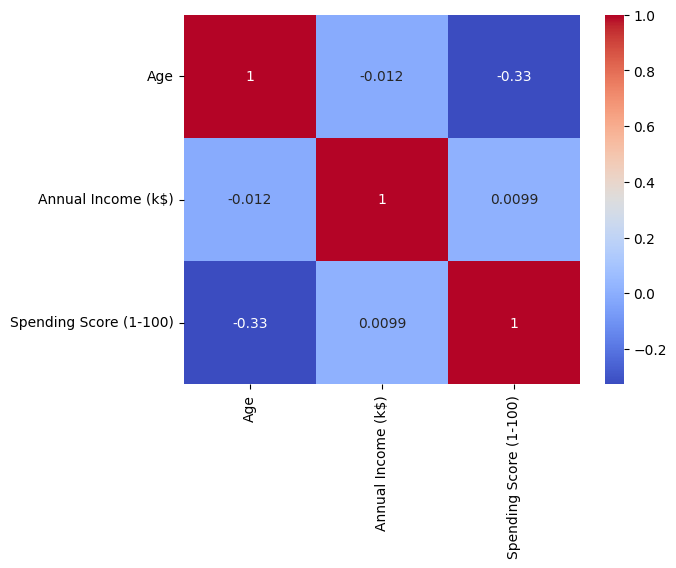

In [95]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')

this ia good way to do EDA and understand the data we dealing with and any of these could be saved and added to presentations.


THIS IS COMPLETION OF EDA


INITIATING KMEANS ALGORITHM

so we can began with clustering and we gonna do univariate clustering bivariate clustering and multivariate clustering and gnn do statistics over those clusters to get insights for our custoner segmentation

In [96]:
#clustering - UNIVARIATE,BIVARIATE,MULTIVARIATE

calling algo
fiiting data
grab or predict the result outta fiited data model 

In [115]:
#initiating algo
clustering1 = KMeans(n_clusters=3)

In [116]:
 #fitting data
clustering1.fit(df[['Age', 'Annual Income (k$)','Spending Score (1-100)']])

KMeans(n_clusters=3)

In [117]:
clustering1.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

now comparing it to our initial data by adding it to our initial df

In [118]:
df['Income Cluster'] = clustering1.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,Male,19,15,39,0
1,Male,21,15,81,0
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0


summarized statistics around univariate cluster

In [119]:
df['Income Cluster'].value_counts()

Income Cluster
0    123
1     39
2     38
Name: count, dtype: int64

we dont know what ideal number of cluster is so we use elbow method to resolbe it.it is a standard method.
it introduce a success matric i.e. inertia that represents the distance between centroids

In [120]:
clustering1.inertia_

143342.75157170603

In [121]:
inertia_score=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df[['Income Cluster']])
    inertia_score.append(kmeans.inertia_)

In [122]:
inertia_score

[124.87500000000003,
 29.611111111111114,
 2.881191196803305e-28,
 2.881191196803305e-28,
 2.881191196803305e-28,
 2.881191196803305e-28,
 2.881191196803305e-28,
 2.881191196803305e-28,
 2.881191196803305e-28,
 2.881191196803305e-28]

now we need to pair these scores with range i.e.plotting

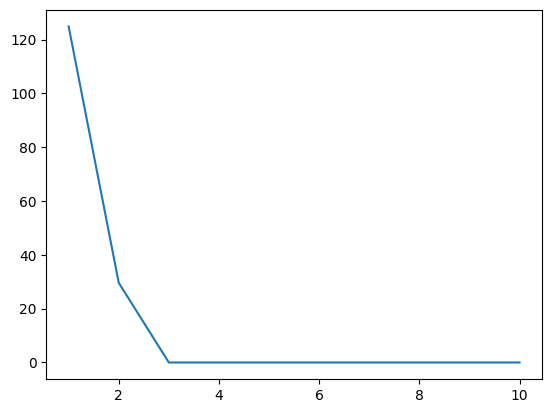

In [123]:
plt.plot(range(1,11),inertia_score)


so it is elboe method but its not a great method coz we have to find wfrom where the elbow has started
its look like elbow has started from 3 so we consider 3 cluster now we change cluster above and run all again in clustering1 where nclusters = 3


In [126]:
#df.coloumns is wrong
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Income Cluster'],
      dtype='object')

In [128]:
#analysis mean values for age spening score by group bby
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,40.325203,44.154472,49.829268
1,32.692308,86.538462,82.128205
2,40.394737,87.000000,18.631579


BIVARIATE CLUSTERING

In [138]:
clustering2=KMeans(n_clusters=5)
clustering2.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
#clustering2.labels_
df['Spending and Income Cluster'] = clustering2.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,0,3
1,Male,21,15,81,0,4
2,Female,20,16,6,0,3
3,Female,23,16,77,0,4
4,Female,31,17,40,0,3


In [139]:
inertia_score2=[]
for i in range(1,11):
    kmeans2=KMeans(n_clusters=i)
    kmeans2.fit(df[['Income Cluster']])
    inertia_score2.append(kmeans2.inertia_)

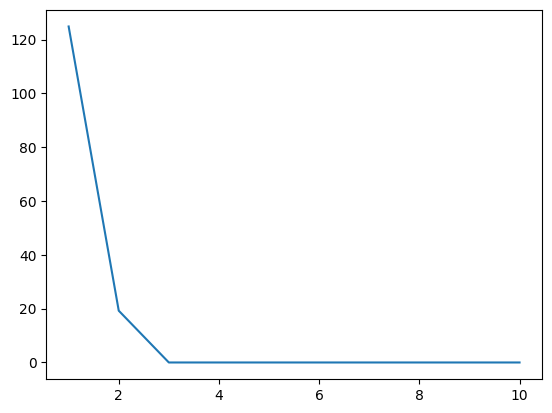

In [140]:
plt.plot(range(1,11),inertia_score2)

in youtube tutorial it shows elbow to start at 5 and acc to my this scenario it says elbow starts with 3

and now we consider n_clusters=elbow start point

lets visualize it using scatter plot

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

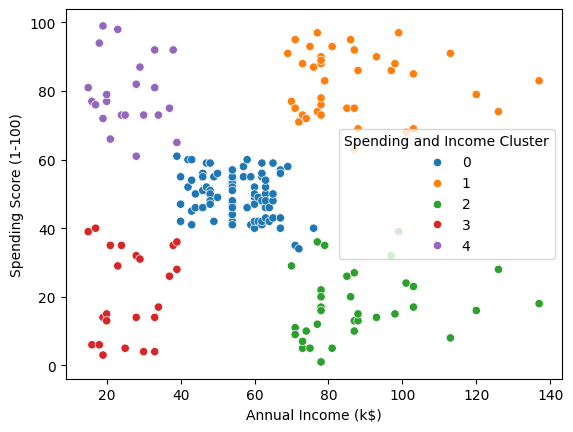

In [142]:
sns.scatterplot(data=df,x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending and Income Cluster',palette='tab10')

In [147]:
clustering2.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636]])

In [146]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers

,0,1
0,55.296296,49.518519
1,86.538462,82.128205
2,88.200000,17.114286
3,26.304348,20.913043
4,25.727273,79.363636


In [149]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x','y']

these are x and y coordinates for centeoid

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

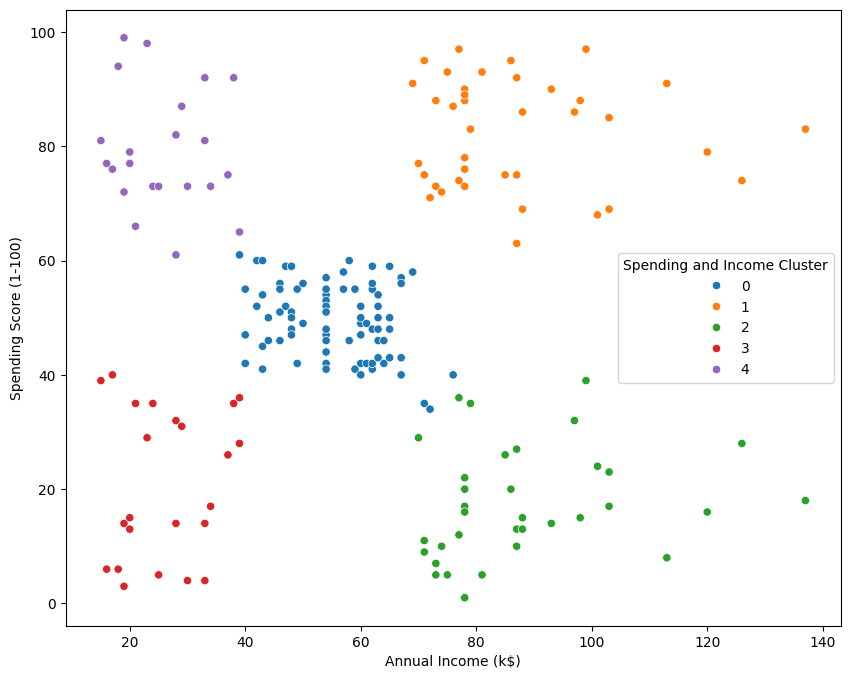

In [143]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending and Income Cluster',palette='tab10')

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

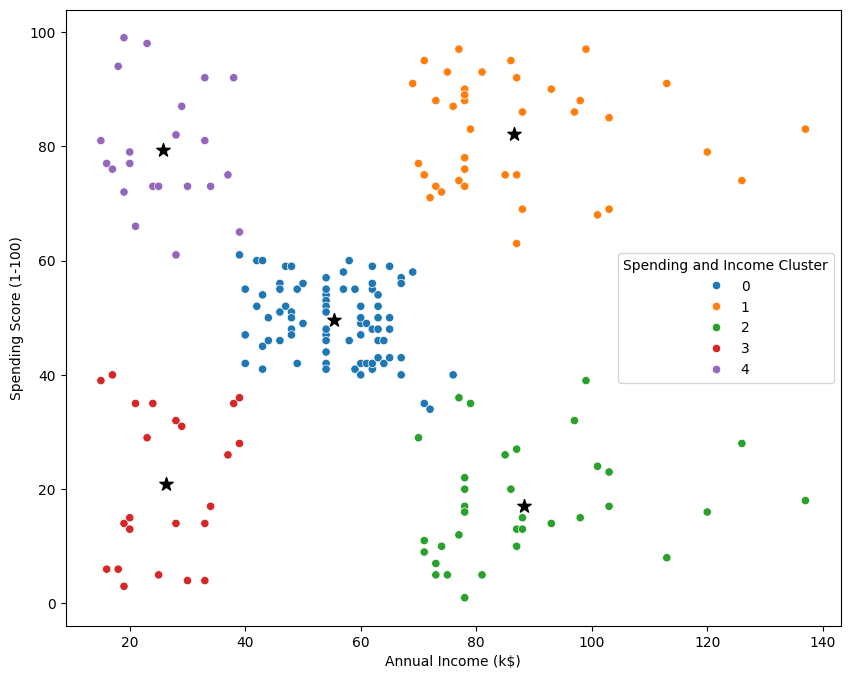

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x=centers['x'],y=centers['y'],s=100,c='black',marker='*')
sns.scatterplot(data=df,x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending and Income Cluster',palette='tab10')
# to save fig
# plt.savefig('clustering_bivariate_fig_1.1.png')

marked perfect centers


for more analysis we could do male and female

In [156]:
pd.crosstab(df['Spending and Income Cluster'],df['Gender'])

Gender,Female,Male
Spending and Income Cluster,,
0,48,33
1,21,18
2,16,19
3,14,9
4,13,9


In [155]:
pd.crosstab(df['Spending and Income Cluster'],df['Gender'],normalize='index')

Gender,Female,Male
Spending and Income Cluster,,
0,0.592593,0.407407
1,0.538462,0.461538
2,0.457143,0.542857
3,0.608696,0.391304
4,0.590909,0.409091


In [158]:
df.groupby('Spending and Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,41.114286,88.200000,17.114286
3,45.217391,26.304348,20.913043
4,25.272727,25.727273,79.363636


cluster 1 has high annual income and spending score so it'll be ideal for us to run campaigns on

MULTIVARIATE CLUSTER

to get algo work correctly we need to scale the data

In [159]:
from sklearn.preprocessing import StandardScaler

In [160]:
scale= StandardScaler()

In [161]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,0,3
1,Male,21,15,81,0,4
2,Female,20,16,6,0,3
3,Female,23,16,77,0,4
4,Female,31,17,40,0,3


data we have we dont need customer id nd other new columns and gender is not a numeric value so we have to take care of it by encoding gender as get_dumies func
we just need age gend3er and spending score

In [162]:
dff = pd.get_dummies(df)
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Female,Gender_Male
0,19,15,39,0,3,False,True
1,21,15,81,0,4,False,True
2,20,16,6,0,3,True,False
3,23,16,77,0,4,True,False
4,31,17,40,0,3,True,False


it has two colums we only need one column zoc we know gender = male+ female and if we have any one of them we can find the ither one 

In [163]:
dff.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Income Cluster',
       'Spending and Income Cluster', 'Gender_Female', 'Gender_Male'],
      dtype='object')

In [165]:
dff = dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Income Cluster','Gender_Male']]
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Gender_Male
0,19,15,39,0,True
1,21,15,81,0,True
2,20,16,6,0,False
3,23,16,77,0,False
4,31,17,40,0,False


In [166]:
dff=pd.DataFrame(scale.fit_transform(dff))

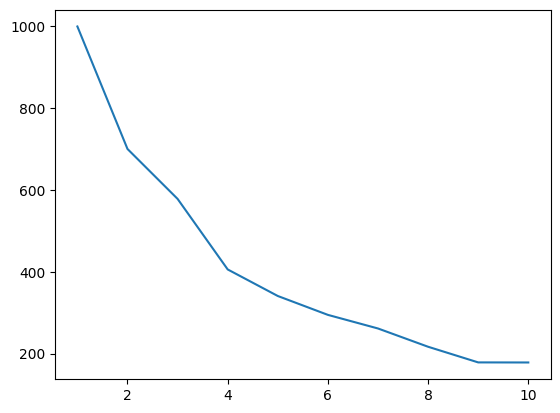

In [169]:
inertia_score3=[]
for i in range(1,11):

    kmeans3=KMeans(n_clusters=i)
    kmeans3.fit(dff)
    
    inertia_score3.append(kmeans3.inertia_)
plt.plot(range(1,11),inertia_score3)

it gave a smooth elbow and is probably arounf 4

In [170]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,0,3
1,Male,21,15,81,0,4
2,Female,20,16,6,0,3
3,Female,23,16,77,0,4
4,Female,31,17,40,0,3
...,...,...,...,...,...,...
195,Female,35,120,79,1,1
196,Female,45,126,28,2,2
197,Male,32,126,74,1,1
198,Male,32,137,18,2,2


In [171]:
df.to_csv('clustering.csv')
